In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm

OUTROOT = "/work/hdd/bdne/nchartier/Q_correction"
NREAL = 50
N_ITER = 3
figroot = "Figures"
os.makedirs(figroot, exist_ok=True)

# Plotting power spectra after Q-corrections

In [2]:
def load_pk_ratio_panel(sim, which):
    '''which: "pm", or "it1"/"it2"/"it3" for the corrected iterations.
    Returns a list of (k, ratio) tuples, one per seed, with ratio = P(k)/P_target(k)
    interpolated onto this field's own k-grid.'''
    results = []
    for seed in range(NREAL):
        d = os.path.join(OUTROOT, sim, "seed%d" % seed)
        k_nb = np.load(os.path.join(d, "k_nb.npy"))
        pk_nb = np.load(os.path.join(d, "pk_nb.npy"))

        if which == "pm":
            k_x = np.load(os.path.join(d, "k_pm.npy"))
            pk_x = np.load(os.path.join(d, "pk_pm.npy"))
        else:
            n = int(which.replace("it", ""))
            k_x = np.load(os.path.join(d, "k_corrected_it%d.npy" % n))
            pk_x = np.load(os.path.join(d, "pk_corrected_it%d.npy" % n))

        pk_nb_i = np.interp(k_x, k_nb, pk_nb)
        results.append((k_x, pk_x / pk_nb_i))
    return results





In [5]:
QUIJOTE_ROOT = "/work/hdd/bdne/nchartier/quijote_lh"

def load_saved_field(sim, seed, which, grid):
    '''which: "nb", "pm", or "it1"/"it2"/"it3".
    "nb" (Quijote target) now lives under quijote_lh/{seed}/, not
    Q_correction/{sim}/seed{seed}/ -- moved there by compute_quijote_products.py.'''
    if which == "nb":
        return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))
    d = os.path.join(CORR_ROOT, sim, "seed%d" % seed)
    return np.load(os.path.join(d, "delta_%s_grid%d.npy" % (which, grid)))


def load_pk_ratio_panel(sim, which):
    results = []
    for seed in range(NREAL):
        d = os.path.join(OUTROOT, sim, "seed%d" % seed)
        k_nb = np.load(os.path.join(QUIJOTE_ROOT, str(seed), "k.npy"))
        pk_nb = np.load(os.path.join(QUIJOTE_ROOT, str(seed), "pk.npy"))

        if which == "pm":
            k_x = np.load(os.path.join(d, "k_pm.npy"))
            pk_x = np.load(os.path.join(d, "pk_pm.npy"))
        else:
            n = int(which.replace("it", ""))
            k_x = np.load(os.path.join(d, "k_corrected_it%d.npy" % n))
            pk_x = np.load(os.path.join(d, "pk_corrected_it%d.npy" % n))

        pk_nb_i = np.interp(k_x, k_nb, pk_nb)
        results.append((k_x, pk_x / pk_nb_i))
    return results


def load_quijote_delta(seed, grid):
    '''Every seed (0-100+) now lives under this same convention, so the old
    seed<=49-vs->49 branching is gone -- that split only existed because 0-49
    used to be split across two different locations.'''
    return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))

def plot_pk_ratio_grid(sim, outfile=None):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True,
                              constrained_layout=True)
    cmap = cm.inferno
    norm = Normalize(vmin=0, vmax=NREAL - 1)

    panels = [
        (axes[0, 0], "pm", "PM / target"),
        (axes[0, 1], "it1", "Corrected (1 iteration) / target"),
        (axes[1, 0], "it2", "Corrected (2 iterations) / target"),
        (axes[1, 1], "it3", "Corrected (3 iterations) / target"),
    ]

    for ax, which, title in panels:
        data = load_pk_ratio_panel(sim, which)
        for seed, (k, ratio) in enumerate(data):
            ax.plot(k, ratio, color=cmap(norm(seed)), lw=1)
        ax.axhline(1.0, color="black", lw=2, ls=":")
        ax.set_xscale("log")
        ax.set_title(title, fontsize=13)
        ax.grid(alpha=0.5, color = "grey")

    fts = 15
    axes[1, 0].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=fts)
    axes[1, 1].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=fts)
    axes[0, 0].set_ylabel(r"$P(k)/P_{\rm target}(k)$", fontsize=fts)
    axes[1, 0].set_ylabel(r"$P(k)/P_{\rm target}(k)$", fontsize=fts)

    for ax in axes.flatten():
        ax.tick_params(labelsize = 14)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.046, pad=0.02, aspect=40)
    cbar.set_label("Seed", fontsize=fts)

    fig.suptitle(sim.upper() + " Q corrections", fontsize=18, weight = "semibold")

    if outfile is not None:
        plt.savefig(outfile, bbox_inches="tight")
    return fig, axes

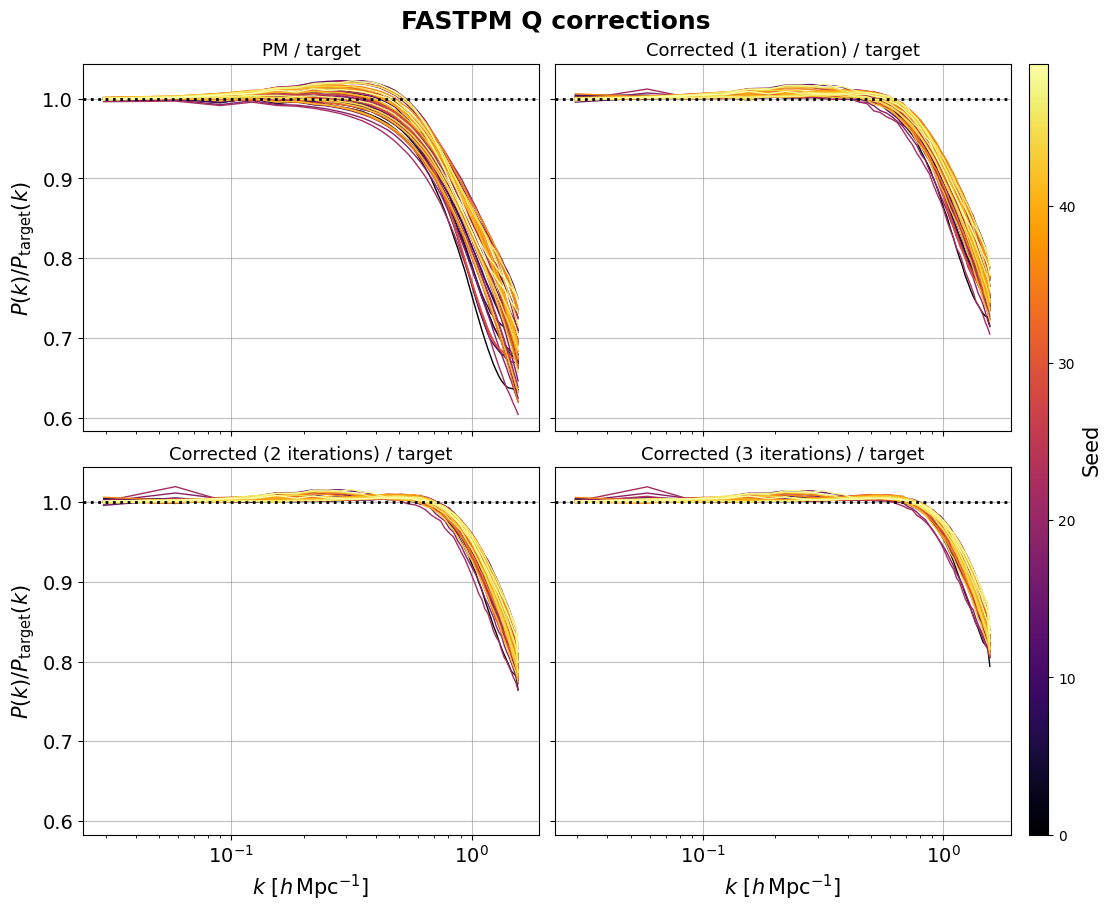

In [6]:
fig, axes = plot_pk_ratio_grid("fastpm", outfile=os.path.join(figroot, "pk_ratio_grid_fastpm.pdf"))


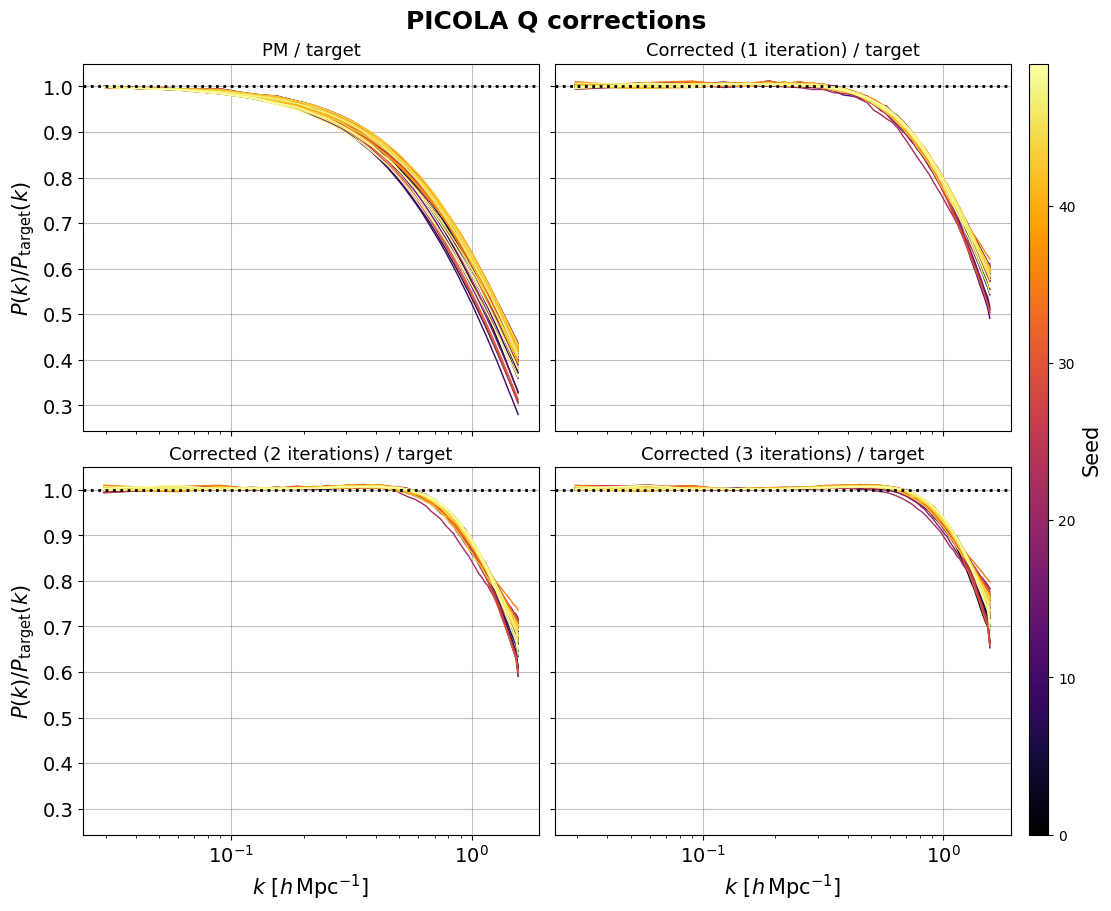

In [7]:
fig, axes = plot_pk_ratio_grid("picola", outfile=os.path.join(figroot, "pk_ratio_grid_picola.pdf"))


In [8]:
CORR_ROOT = "/work/hdd/bdne/nchartier/Q_correction"

def get_boxsize(seed):
    path = "/work/hdd/bdne/nchartier/quijote_lh/%d/snap_003" % seed
    header = readgadget.header(path)
    return header.boxsize / 1e3


def load_saved_field(sim, seed, which, grid):
    '''which: "nb", "pm", or "it1"/"it2"/"it3"'''
    d = os.path.join(CORR_ROOT, sim, "seed%d" % seed)
    if which in ("nb", "pm"):
        fname = "delta_%s_grid%d.npy" % (which, grid)
    else:
        n = int(which.replace("it", ""))
        fname = "delta_corrected_it%d_grid%d.npy" % (n, grid)
    return np.load(os.path.join(d, fname))


def slice_2d(delta_3d, BoxSize, grid, x_min, x_max, y_min, y_max, z_min, z_max):
    '''z-averaged 2D (1+delta) slice out of a saved 3D delta grid.'''
    cell = BoxSize / grid
    ix_min, ix_max = int(round(x_min / cell)), int(round(x_max / cell))
    iy_min, iy_max = int(round(y_min / cell)), int(round(y_max / cell))
    iz_min, iz_max = int(round(z_min / cell)), int(round(z_max / cell))
    iz_max = max(iz_max, iz_min + 1)
    sub = delta_3d[ix_min:ix_max, iy_min:iy_max, iz_min:iz_max]
    return 1.0 + sub.mean(axis=2)


In [9]:
def plot_fields_slices(fields, labels, x_min, x_max, y_min, y_max, z_min, z_max,
                        scale='log', colmap='hot', dmin=0.1, dmax=100,
                        smooth_sigma=None, figroot=None, fname='dfield_slices.pdf'):
    '''Lower-level: plot a list of already-computed 2D (1+delta) fields.'''
    from scipy.ndimage import gaussian_filter

    n = len(fields)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5.5),
                              sharey=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    fields = [np.clip(gaussian_filter(f, sigma=smooth_sigma) if smooth_sigma is not None else f,
                       dmin, dmax) for f in fields]

    vmin = min(f.min() for f in fields)
    vmax = max(f.max() for f in fields)
    norm = LogNorm(vmin=vmin, vmax=vmax) if scale == 'log' else \
           plt.Normalize(vmin=vmin, vmax=vmax)

    extent = [x_min, x_max, y_min, y_max]
    im = None
    for ax, field, label in zip(axes, fields, labels):
        im = ax.imshow(field.T, origin='lower', extent=extent,
                        cmap=colmap, norm=norm,
                        interpolation='sinc', aspect='equal')
        ax.set_title(label, fontsize=14)
        ax.set_xlabel(r'$x\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
    axes[0].set_ylabel(r'$y\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)

    cbar = fig.colorbar(im, ax=axes, fraction=0.05, pad=0.02, aspect=30)
    cbar.set_label(r'$1+\delta$', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    fig.suptitle(r'$z \in [%.1f,\,%.1f]\ h^{-1}\mathrm{Mpc}$' % (z_min, z_max),
                  fontsize=16)

    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, fname), bbox_inches="tight")
    return fig, axes


def plot_density_slices(pos_list, labels, BoxSize, grid,
                         x_min, x_max, y_min, y_max, z_min, z_max,
                         scale='log', colmap='hot', dmin=0.1, dmax=100,
                         smooth_sigma=None, figroot=None,
                         fname='dfield_slices.pdf'):
    '''Original position-based version, now just a thin wrapper.'''
    fields = [compute_density_slice_2d(pos, BoxSize, grid,
                                        x_min, x_max, y_min, y_max, z_min, z_max)
              for pos in pos_list]
    return plot_fields_slices(fields, labels, x_min, x_max, y_min, y_max, z_min, z_max,
                               scale=scale, colmap=colmap, dmin=dmin, dmax=dmax,
                               smooth_sigma=smooth_sigma, figroot=figroot, fname=fname)



In [10]:
import readgadget
import bigfile

def load_quijote(seed):
    path = "/work/hdd/bdne/nchartier/quijote_lh/%d/snap_003" % seed
    header = readgadget.header(path)
    BoxSize = header.boxsize / 1e3
    pos = readgadget.read_block(path, "POS ", [1]) / 1e3
    return pos, BoxSize

def load_fastpm(seed):
    path = "/work/hdd/bdne/maho3/cmass-ili/quijotelike_for_nicolas/fastpm/L1000-N128/%d/fastpm_B2_0.6667" % seed
    infile = bigfile.File(path)
    return infile['1/Position'][:]

def load_lpicola(seed):
    path = "/work/hdd/bdne/nchartier/cola_lh/%d/Cola%d_512_20stepsnLPTpos0p5_z0p500" % (seed, seed)
    return readgadget.read_block(path, "POS ", [1]) / 1e3


In [13]:
def plot_stage_comparison(seed, stage, grid=512,
                           x_min=0., x_max=600., y_min=0., y_max=600.,
                           z_min=490., z_max=510.,
                           dmin=0.9, dmax=80, smooth_sigma=1.0,
                           figroot=figroot):
    '''stage: 0 for the initial (uncorrected) fields, 1/2/3 for that many
    Q-correction iterations. Plots Quijote (target) + L-PICOLA + FastPM at
    that stage, all sliced from run_Q_correction.py's saved density grids.'''
    if stage not in (0, 1, 2, 3):
        raise ValueError("stage must be 0, 1, 2, or 3, got %r" % stage)

    which = "pm" if stage == 0 else "it%d" % stage
    stage_label = "initial" if stage == 0 else "%d correction%s" % (stage, "s" if stage > 1 else "")

    BoxSize = get_boxsize(seed)

    field_nb = load_saved_field("picola", seed, "nb", grid)  # nb is identical under either sim folder
    field_picola = load_saved_field("picola", seed, which, grid)
    field_fastpm = load_saved_field("fastpm", seed, which, grid)

    fields_2d = [slice_2d(f, BoxSize, grid, x_min, x_max, y_min, y_max, z_min, z_max)
                 for f in (field_nb, field_picola, field_fastpm)]

    return plot_fields_slices(
        fields_2d,
        ["Quijote (target)", "L-PICOLA (%s)" % stage_label, "FastPM (%s)" % stage_label],
        x_min, x_max, y_min, y_max, z_min, z_max,
        scale='log', colmap='hot', dmin=dmin, dmax=dmax,
        smooth_sigma=smooth_sigma, figroot=figroot,
        fname="dfield_slices_seed%d_stage%d.pdf" % (seed, stage))


In [14]:
fig, axes = plot_stage_comparison(seed=7, stage=1)

FileNotFoundError: [Errno 2] No such file or directory: '/work/hdd/bdne/nchartier/Q_correction/quijote_lh/seed7/delta_nb_grid512.npy'

# Trying PQMass

## 2d tests

## 3d tests